# Bloom evaluation

Quick checks on the Bloom duplicate tracker: per-minute dup rate trends and an exact vs Bloom comparison on a recent window.

In [13]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# Find project root: notebook is in notebooks/, delta/ is in project root
if "__file__" in globals():
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
else:
    # In Jupyter, Path.cwd() might be notebooks/ or project root
    cwd = Path.cwd()
    if cwd.name == "notebooks":
        PROJECT_ROOT = cwd.parent
    elif (cwd / "delta").exists():
        PROJECT_ROOT = cwd
    else:
        # Try going up one level
        parent = cwd.parent
        if (parent / "delta").exists():
            PROJECT_ROOT = parent
        else:
            PROJECT_ROOT = cwd  # Fallback

DELTA_DIR = PROJECT_ROOT / "delta"

In [14]:
dup_metrics_path = DELTA_DIR / "gold_dup_rate_1m"
if not dup_metrics_path.exists():
    raise FileNotFoundError(
        f"Missing {dup_metrics_path}. Run spark/stream_reviews.py and producer/send_reviews.py first."
    )

dup_metrics = pd.read_parquet(dup_metrics_path).sort_values("window_start")
print(f"Loaded {len(dup_metrics):,} minute buckets")
dup_metrics.tail()

Loaded 5,999 minute buckets


,window_start,total,dup_count,dup_rate
5544,2022-01-15 09:33:00,1,0,0.0
5882,2022-01-16 04:59:00,1,1,1.0
5545,2022-01-16 04:59:00,1,0,0.0
5546,2022-01-19 12:47:00,1,0,0.0
5874,2022-01-19 12:47:00,1,1,1.0


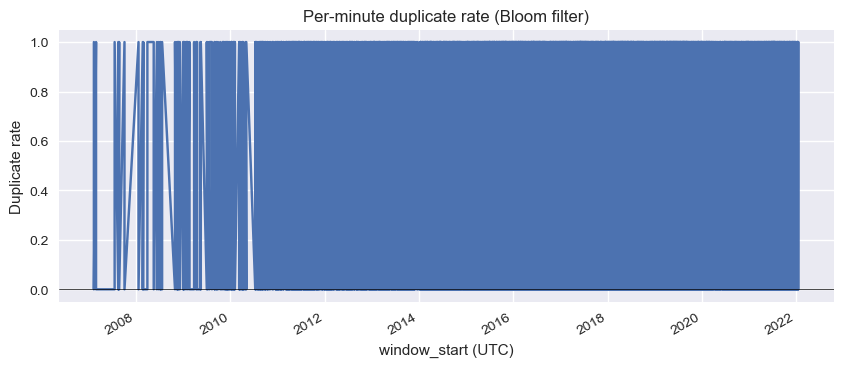

In [15]:
ax = dup_metrics.set_index("window_start")["dup_rate"].plot(figsize=(10, 4))
ax.set_ylabel("Duplicate rate")
ax.set_xlabel("window_start (UTC)")
ax.set_title("Per-minute duplicate rate (Bloom filter)")
ax.axhline(0, color="black", linewidth=0.5)
plt.show()

In [18]:
bloom_dup_path = DELTA_DIR / "dup_bloom"
bronze_path = DELTA_DIR / "bronze_reviews"

if not bloom_dup_path.exists() or not list(bloom_dup_path.glob("*.parquet")):
    raise FileNotFoundError(
        f"No Bloom duplicate rows at {bloom_dup_path}. Keep the stream running and replay reviews first."
    )

bloom_dup = pd.read_parquet(bloom_dup_path)
bloom_dup["window_start"] = pd.to_datetime(bloom_dup["event_time"]).dt.floor("min")
if bloom_dup.empty:
    raise ValueError("Bloom duplicate table is empty")

bronze_files = sorted(bronze_path.rglob("*.parquet"))
if not bronze_files:
    raise FileNotFoundError(f"No bronze review files found under {bronze_path}")

# Load a sample of bronze files (last 20 for efficiency, or adjust as needed)
sample_size = min(20, len(bronze_files))
print(f"Loading last {sample_size} bronze files from {len(bronze_files)} total files...")
bronze_pdf = pd.concat(pd.read_parquet(p) for p in bronze_files[-sample_size:])
bronze_pdf["event_time"] = pd.to_datetime(bronze_pdf["event_time"])
bronze_pdf["window_start"] = bronze_pdf["event_time"].dt.floor("min")

# Find windows that exist in both bloom_dup and bronze_pdf
bloom_windows = set(bloom_dup["window_start"].unique())
bronze_windows = set(bronze_pdf["window_start"].unique())
common_windows = sorted(bloom_windows & bronze_windows)

if not common_windows:
    raise ValueError(
        f"No overlapping windows found. "
        f"Bloom windows: {len(bloom_windows)}, Bronze windows: {len(bronze_windows)}. "
        f"Try loading more bronze files or check time ranges."
    )

# Select the most recent common window
target_window = common_windows[-1]
print(f"Evaluating window starting at {target_window}")
print(f"Found {len(common_windows)} overlapping windows, using the most recent one.")

bronze_window = bronze_pdf.loc[
    bronze_pdf["window_start"] == target_window
].copy()
if bronze_window.empty:
    raise ValueError(f"No bronze rows for window {target_window}")

bronze_window["norm_key"] = (
    bronze_window["user_id"].fillna("")
    + "||"
    + bronze_window["business_id"].fillna("")
    + "||"
    + bronze_window["text"].fillna("").str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)
exact_dups = bronze_window[bronze_window["norm_key"].duplicated(keep=False)]

bloom_ids = set(bloom_dup.loc[bloom_dup["window_start"] == target_window, "review_id"])
exact_ids = set(exact_dups["review_id"])
true_positives = len(bloom_ids & exact_ids)
precision = true_positives / len(bloom_ids) if bloom_ids else float("nan")
recall = true_positives / len(exact_ids) if exact_ids else float("nan")

print(
    f"Bloom flagged {len(bloom_ids)} reviews, {true_positives} were true duplicates.\n"
    f"Exact duplicates in window: {len(exact_ids)}\n"
    f"Precision: {precision:.2%} | Recall: {recall:.2%}"
)

Loading last 20 bronze files from 407 total files...
Evaluating window starting at 2022-01-09 05:37:00
Found 183 overlapping windows, using the most recent one.
Bloom flagged 1 reviews, 0 were true duplicates.
Exact duplicates in window: 0
Precision: 0.00% | Recall: nan%
